In [2]:
import numpy as np
import tensorflow as tf
import keras
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

import sys
from scipy.integrate import simpson
sys.path.append("..")
import LJ_lmft_utils as lmft
import neural_utils as neural
import LJEOS as eos

from feos.eos import EquationOfState, State, Contributions
from feos.pets import PetsParameters
import feos.si as si

# Enable or disable Tensor Float 32 Execution
tf.config.experimental.enable_tensor_float_32_execution(False)

plt.rcParams["font.size"] = 10

In [3]:
def LJ_wall(position, low, high, epsilon=2, sigma=1):
    r_low = position - low
    r_high = high - position
    
    energy_low = 4 * epsilon * ((sigma / r_low)**12 - (sigma / r_low)**6)
    energy_high = 4 * epsilon * ((sigma / r_high)**12 - (sigma / r_high)**6)
    
    return np.where((position >= high) | (position <= low), 1e30, energy_low + energy_high)

    
def get_betaFexc(model_path, zbins, rho_A, rho_B, T, dx=0.005, L=30, rho_b_a = None, rho_b_b = None,
                  eps_AA=1.0, eps_BB=1.0, int_param=0.0, sigma_AA=1.0, sigma_BB=1.0, rc=2.5
                  ):
    """
    Calculate the excess free energy Fexc for a given density profile with functional line integration
    for a long range system using LMFT.

    model: The neural correlation functional
    rho: The density profile
    T: Temperature
    dx: The discretization of the input layer of the model
    L: Length of box
    rc: LJ cutoff
    rho_b: Bulk density to use to calculate mu_R for delta mu.
            If unspecified, assume confined fluid where rho_b is the value at the middle of the density profile.
    """

    model = keras.models.load_model(model_path)

    alphas = np.linspace(0, 1, 50)
    integrands = np.empty_like(alphas)

    if rho_b_a is None:
        rho_b_a = rho_A[int(len(rho_A)/2)] # Taken to be middle of slit

    if rho_b_b is None:
        rho_b_b = rho_B[int(len(rho_B)/2)]

    rho_tot = rho_b_a + rho_b_b
    beta = 1/T

    eps_AB = (1-int_param) * np.sqrt(eps_AA*eps_BB)
    sigma_AB = 0.5 * (sigma_AA + sigma_BB)

    potential_array_AA = lmft.attract(zbins, eps=eps_AA, sig=sigma_AA, cutoff=rc)
    potential_array_AB = lmft.attract(zbins, eps=eps_AB, sig=sigma_AB, cutoff=rc)
    potential_array_BB = lmft.attract(zbins, eps=eps_BB, sig=sigma_BB, cutoff=rc)

    for i, alpha in enumerate(alphas):

        # Calculate delta mu
        c1_sr_b = neural.c1_onetype_T(model, alpha*rho_tot*np.ones_like(rho_A), T*np.ones_like(rho_A), input_bins=1201)
        mu_R_A = np.log(alpha*rho_b_a) - c1_sr_b
        mu_R_B = np.log(alpha*rho_b_b) - c1_sr_b

        if alpha == 0:
            mu_correction_A = np.zeros_like(rho_A)
            mu_correction_B = np.zeros_like(rho_B)

        else:
            try:
                mu_LR = eos.calc_mu_mixture([alpha*rho_b_a, alpha*rho_b_b], T,
                                        np.array([eps_AA, eps_BB]),
                                        np.array([sigma_AA, sigma_BB]),
                                        k_ij = np.array([[0, int_param], [int_param, 0]]),
                                        )
                mu_A = mu_LR[0]
                mu_B = mu_LR[1]
                
                mu_correction_A = mu_A - T*mu_R_A
                mu_correction_B = mu_B - T*mu_R_B

            except RuntimeError as e:
                if "Invalid state in validate: moles = NaN" in str(e):
                    mu_correction_A = np.zeros_like(rho_A)
                    mu_correction_B = np.zeros_like(rho_B)
                else:
                    raise  # Re-raise if it's a different RuntimeError


        mu_correction_A[rho_A == 0] = 0
        mu_correction_B[rho_B == 0] = 0

        V_correction_AA = lmft.V_correction(dx, alpha*(rho_A - rho_b_a), potential_array_AA)
        V_correction_AB = lmft.V_correction(dx, alpha*(rho_B - rho_b_b), potential_array_AB)
        V_correction_BA = lmft.V_correction(dx, alpha*(rho_A - rho_b_a), potential_array_AB)
        V_correction_BB = lmft.V_correction(dx, alpha*(rho_B - rho_b_b), potential_array_BB)

        c1_pred_SR = neural.c1_onetype_T(model, alpha*(rho_A+rho_B), T*np.ones_like(rho_A), input_bins=1201)

        c1_LR_A = c1_pred_SR + beta*(V_correction_AA + V_correction_AB) - beta*mu_correction_A
        c1_LR_B = c1_pred_SR + beta*(V_correction_BB + V_correction_BA) - beta*mu_correction_B

        integrands[i] = simpson(rho_A * c1_LR_A + rho_B * c1_LR_B, dx = dx)
        
    Fexc = -simpson(integrands, x=alphas)

    return Fexc, c1_LR_A, c1_LR_B


def grand_pot(model_path, xbins, rho_A, rho_B, T, mu_A, mu_B, Vext_A, Vext_B, L=30, rho_bulk_A=None, rho_bulk_B = None,
              eps_AA=1.0, eps_BB=1.0, int_param=0.0, sigma_AA=1.0, sigma_BB=1.0, rc=2.5
              ):
    # This is the beta grand potential per unit area

    Fex, c1_LR_A, c1_LR_B = get_betaFexc(model_path, xbins, rho_A, rho_B, T, rho_b_a = rho_bulk_A, rho_b_b = rho_bulk_B,
                                          eps_AA=eps_AA, eps_BB=eps_BB, int_param=int_param,
                                          sigma_AA=sigma_AA, sigma_BB=sigma_BB, rc=rc
                                            )

    valid_A = (rho_A > 0)
    valid_B = (rho_B > 0)

    Fid = (simpson(rho_A[valid_A] * (np.log(rho_A[valid_A]) - 1), dx=0.005) +
             simpson(rho_B[valid_B] * (np.log(rho_B[valid_B]) - 1), dx=0.005) )

    integral = simpson(rho_A[valid_A] * (Vext_A[valid_A] - mu_A), x=xbins[valid_A]) + simpson(rho_B[valid_B] * (Vext_B[valid_B] - mu_B), x=xbins[valid_B])

    return Fid + Fex + integral


def integrate_profile(df, x_min, x_max, column="rho_A"):
    """
    Integrate the density profile between x_min and x_max to get Gamma.
    """
    mask = df["x_centered"].between(x_min, x_max)
    sub = df.loc[mask].sort_values("x_centered")
    return np.trapezoid(sub[column], x=sub["x_centered"])


def compute_H_from_profile(df_rho, rho_bulk, column="rho_B", H_min=None, H_max=None):
    """
    Integrate the density over a range of trial H values and fit Gamma vs H
    to find the H where Gamma = 0.
    """
    if H_min is None:
        H_min = 0.0
    if H_max is None:
        H_max = df_rho["x_centered"].max() - df_rho["x_centered"].min()

    Hrange = np.arange(H_min, H_max, 0.01)
    results = []

    for H in Hrange:
        Gamma = integrate_profile(df_rho, -0.5*H, 0.5*H, column=column) - H*rho_bulk
        results.append((H, Gamma))

    df_ads = pd.DataFrame(results, columns=["H", "Gamma"])

    # Fit linearly near the maximum H to find zero crossing
    df_fit = df_ads.loc[df_ads["H"].between(Hrange[-10], Hrange[-1])]
    coeffs = np.polyfit(df_fit["H"], df_fit["Gamma"], 1)

    H_zero = -coeffs[1] / coeffs[0]
    return H_zero, df_ads


def pred_gamma(omega, pressure, L):
    return 0.5 * (omega + pressure*L)


def pred_S(GammaA, H, rhobar):

    #S_B = 1 / (1 + GammaA/(H*rhobar)) # Should be valid for all GammaA
    S_B = 1 - GammaA/(H*rhobar) # Linearised form valid for small GammaA

    return S_B


def pred_dSdx(mol_frac, GammaA_list, H_list, rhobar_list):

    dGammaA_dxB = np.gradient(GammaA_list, mol_frac)
    drhobar_dxB = np.gradient(rhobar_list, mol_frac)

    dSdx = (-1/(H_list*rhobar_list)) * dGammaA_dxB + ((1*GammaA_list)/(H_list*rhobar_list**2))*drhobar_dxB

    return dSdx


def pred_dSdepsw(del_eps, GammaA_list, H_list, rhobar):

    dGammaA_deps = np.gradient(GammaA_list, del_eps)

    dSdeps = (-1/(H_list*rhobar)) * dGammaA_deps

    return dSdeps


def pred_dgammadx(mol_frac, GammaA_list, mu_A_list):

    dmuA_dxB = np.gradient(mu_A_list, mol_frac)
    dgamma_dx = (-GammaA_list/2) * dmuA_dxB

    return dgamma_dx

In [4]:

def find_zero_crossings(x_data, y_data):
    zero_crossings = []
    for i in range(len(x_data) - 1):
        x0, y0 = x_data[i], y_data[i]
        x1, y1 = x_data[i + 1], y_data[i + 1]
        if y0 == 0:
            zero_crossings.append(x0)
        elif y0 * y1 < 0:
            x_zero = x0 - y0 * (x1 - x0) / (y1 - y0)
            zero_crossings.append(x_zero)
    if y_data[-1] == 0:
        zero_crossings.append(x_data[-1])
    if zero_crossings == []:
        zero_crossings = [np.nan]
    return zero_crossings

def calculate_cross_points(eps_B, eps_wall_A, L_range, mol_frac):
    # L here is the actual slit width
    
    greatest_extent_B = np.full((len(L_range), len(eps_wall_A), len(mol_frac)), np.nan)
    cross_point = np.full((len(L_range), len(eps_wall_A)), np.nan)

    # Loop over slit widths
    for l, L in enumerate(L_range):
        for a, x in enumerate(mol_frac):
            for i, eps_A in enumerate(eps_wall_A):
                df_select = pd.read_csv(
                    f"../data/results/selectivity/varying_eps_w/{eps_B:.3f}/capillary_{eps_A:.3f}/{x:.2f}/oversolubility.dat",
                    delimiter=" ", header=None, skiprows=1
                )
                idx_select = abs(df_select[0] - (L+3)).idxmin()
                greatest_extent_B[l, i, a] = df_select[7][idx_select]

        for i in range(len(eps_wall_A)):
            cross_point[l, i] = find_zero_crossings(mol_frac, greatest_extent_B[l, i, :]-1)[0]

    return cross_point, greatest_extent_B


def get_properties(eps_B, eps_wall, L, mol_frac, T, pressure):
    # L here is the actual slit width

    S_A = np.empty((len(eps_wall), len(mol_frac)))
    S_B =  np.empty((len(eps_wall), len(mol_frac)))
    rhobar =  np.empty_like(mol_frac)
    mu_A =  np.empty_like(mol_frac)
    gamma =  np.empty((len(eps_wall), len(mol_frac)))
    gamma_L =  np.empty((len(eps_wall), len(mol_frac)))
    H =  np.empty((len(eps_wall), len(mol_frac)))
    GammaA =  np.empty((len(eps_wall), len(mol_frac)))
    omega = np.empty((len(eps_wall), len(mol_frac)))

    for a, x in enumerate(mol_frac):
        s = State(
        eos=pets_azeo,
        temperature=T*si.KELVIN,
        molefracs = np.array([1-x, x]),
        pressure = pressure * (si.KELVIN * si.KB / si.ANGSTROM**3)
        )

        rho_tot = s.density * si.NAV * si.ANGSTROM**3
        rhobar[a] = rho_tot
        rho_mixture = rho_tot*np.array([1-x, x])
        betamu = s.chemical_potential(Contributions.Residual) / (si.RGAS* T*si.KELVIN) + np.log(rho_mixture)
        mu_A[a] = betamu[0]*T

        for i, eps in enumerate(eps_wall):

            filename = f"../data/results/selectivity/varying_eps_w/{eps_B:.3f}/capillary_{eps:.3f}/{x:.2f}/profiles/lr_pred_capillary_{L+3:.2f}_1.out"
            
            df = pd.read_csv(filename, sep= " ")

            xbins = df["xbins"].to_numpy()
            rho_A = df["rho_A"].to_numpy()
            rho_B = df["rho_B"].to_numpy()
            
            omega_path = f"../data/results/selectivity/varying_eps_w/{eps_B:.3f}/capillary_{eps:.3f}/{x:.2f}/grand_potential.dat"
            if os.path.exists(omega_path):
                df_omega = pd.read_csv(omega_path,
                                    delimiter=" ", header=None, skiprows=1)
                idx_select = abs(df_omega[0] - (L+3)).idxmin()
                omega[i, a] = df_omega[1][idx_select] # omega
            else:
                print(f"Not found omega for eps_B {eps_B:.3f} eps_A {eps:.3f} x {x:.2f}; calculating...")
                Vext_A = LJ_wall(xbins, width, L+width, eps)
                Vext_B = LJ_wall(xbins, width, L+width, eps_B)
                # beta omega
                omega[i, a] = grand_pot(model_path, xbins, rho_A, rho_B, T,
                            betamu[0], betamu[1], Vext_A, Vext_B, L,
                            rho_bulk_A = rho_mixture[0], rho_bulk_B = rho_mixture[1],
                            eps_AA=eps_AA, eps_BB=eps_BB, int_param=int_param)
                omega[i, a] = T*omega[i, a]
    
            N_A = np.trapezoid(rho_A, x=xbins) / L
            N_B = np.trapezoid(rho_B, x=xbins) / L
            N_tot = N_A + N_B

            x_A_slit = N_A/N_tot
            x_B_slit = N_B/N_tot

            S_A[i, a] = x_A_slit / (1 - x)
            S_B[i, a] = x_B_slit / x

            gamma_L[i, a] = pred_gamma(omega[i, a], pressure, L)

            df_rho = df
            df_rho["x_centered"] = df_rho["xbins"] - df_rho["xbins"].mean()
            H[i, a], _ = compute_H_from_profile(df_rho, rho_mixture[1], column="rho_B", H_min=L-6, H_max=L+10)
            GammaA[i, a] = integrate_profile(df_rho, -0.5*H[i, a], 0.5*H[i, a], column="rho_A") - H[i, a]*rho_mixture[0]

            gamma[i, a] = pred_gamma(omega[i, a], pressure, H[i, a])

    return S_B, GammaA, gamma, rhobar, mu_A, H, omega, gamma_L


In [5]:
eps_AA = 1.0
eps_BB = 0.9
int_param = 0.15
sigma = np.ones((2))

parameters = PetsParameters.from_lists(sigma = sigma,
                                       epsilon_k = np.array([eps_AA, eps_BB]),
                                       k_ij = np.array([[0, int_param], [int_param, 0]])
                                       )

pets_azeo = EquationOfState.pets(parameters)


In [6]:
delta_eps_w = np.linspace(-0.5, 0.5, num=51)
mol_frac = np.linspace(0.02, 0.98, num=25) # To calculate x_an
mol_frac2 = np.linspace(0.01, 0.99, num=99) # For more precise crossing points
eps_wall_A_to_plot = [1.8, 2.0, 2.2]
T = 0.77
p = 0.0248
L = 8.0
width = 1.5
L_to_plot = [5.0, 8.0, 20.0, 50.0]
model_path = "../../models/WCA.keras"
eps_B_range = [2.0]
x_an = []

for j, eps_B in enumerate(eps_B_range):
    eps_wall_range_A = eps_B - delta_eps_w
    cross_point, greatest_extent_B = calculate_cross_points(eps_B, eps_wall_range_A, L_to_plot, mol_frac)
    x_an.append(cross_point)
    
S_B, GammaA, gamma, rhobar, mu_A, H_list, omega, gamma_L = get_properties(2.0, eps_wall_A_to_plot, L, mol_frac2, T, p)

x_an = np.array(x_an)
print(x_an.shape)

8.0
(1, 4, 51)


In [7]:
x_az = 0.67

s = State(
    eos=pets_azeo,
    temperature=T*si.KELVIN,
    molefracs = np.array([1-x_az, x_az]),
    pressure = p * (si.KELVIN * si.KB / si.ANGSTROM**3)
    )

rhobar_azeo = s.density * si.NAV * si.ANGSTROM**3
rho_mixture = rhobar_azeo*np.array([1-x_az, x_az])

SB_vary = np.empty((len(eps_B_range), len(delta_eps_w), len(L_to_plot)))

for j, eps_B in enumerate(eps_B_range):
    for i, del_eps in enumerate(delta_eps_w):
        eps_A = eps_B - del_eps

        for l, SB_L in enumerate(L_to_plot):
            
            filename = f"../data/results/selectivity/varying_eps_w/{eps_B:.3f}/capillary_{eps_A:.3f}/{x_az:.2f}/profiles/lr_pred_capillary_{SB_L+3:.2f}_1.out"
            
            df = pd.read_csv(filename, sep= " ")

            xbins = df["xbins"].to_numpy()
            rho_A = df["rho_A"].to_numpy()
            rho_B = df["rho_B"].to_numpy()

            N_A = np.trapezoid(rho_A, x=xbins) / SB_L
            N_B = np.trapezoid(rho_B, x=xbins) / SB_L
            N_tot = N_A + N_B

            x_A_slit = N_A/N_tot
            x_B_slit = N_B/N_tot

            SB_vary[j, i, l] = x_B_slit / x_az

print(SB_vary.shape)

(1, 51, 4)


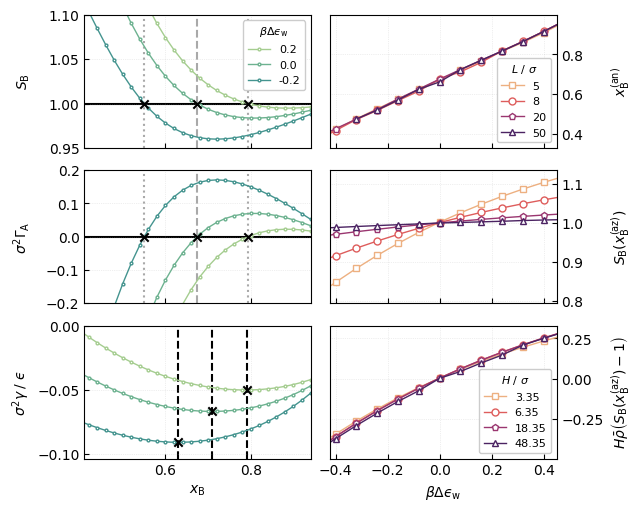

In [10]:

fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(6.3, 5), sharex="col", layout="constrained")
axs = ax.flatten()

######### Master Curve
plot_colour_B2 = sns.color_palette("flare", as_cmap=True)(np.linspace(0, 1, len(L_to_plot)))
cmap_A = sns.color_palette("flare", as_cmap=True)
plot_colour_A = cmap_A(np.linspace(0, 1, len(L_to_plot)))
plot_every = 4
shapes = ["s", "o", "p", "^"]

for i, eps_B in enumerate(eps_B_range):
    for j, L in enumerate(L_to_plot):
        axs[1].plot(delta_eps_w[1::plot_every], x_an[i][j][1::plot_every], color=plot_colour_B2[j],
                   markersize = 5, markerfacecolor="white", lw=1, label=f"{L:.0f}" if i == 0 else "",
                   marker=shapes[j])
        
        axs[3].plot(delta_eps_w[1::plot_every], SB_vary[i, :, j][1::plot_every], markersize=5, color=plot_colour_A[j], lw=1, markerfacecolor="white",
                    marker=shapes[j])
        
        H = L - 1.65
        y = H*rhobar_azeo*(SB_vary[i, :, j] - 1)
        axs[5].plot(delta_eps_w[1::plot_every], y[1::plot_every], markersize=5, color=plot_colour_A[j], lw=1, markerfacecolor="white",
                label=f"{H}", marker=shapes[j])


axs[1].legend(title="$L$ / $\\sigma$", fontsize=8, title_fontsize=8, facecolor="white", framealpha=1,)
axs[5].legend(title="$H$ / $\\sigma$", fontsize=8, title_fontsize=8, facecolor="white", framealpha=1,)

################
cmap_B3 = sns.color_palette("crest", as_cmap=True)
plot_colour_B = cmap_B3(np.linspace(0, 1, 6))
plot_every = 2

for i in range(len(eps_wall_A_to_plot)):
    mid_idx = len(eps_wall_A_to_plot) // 2


    axs[0].plot(mol_frac2[1::plot_every], S_B[i][1::plot_every], '-o',
                markersize=2, color=plot_colour_B[i],
                lw=1, markerfacecolor="white",
                label=f"{2.0 - eps_wall_A_to_plot[i]:.1f}")

    axs[2].plot(mol_frac2[1::plot_every], GammaA[i][1::plot_every], '-o',
                markersize=2, color=plot_colour_B[i],
                lw=1, markerfacecolor="white",
                )

    axs[4].plot(mol_frac2[1::plot_every], gamma[i][1::plot_every], '-o',
                markersize=2, color=plot_colour_B[i],
                lw=1, markerfacecolor="white",
                )
    
    
    x_zero_SB = find_zero_crossings(mol_frac2, S_B[i]-1)
    x_zero_GammaA = find_zero_crossings(mol_frac2, GammaA[i])

    # Plot crosses at zero
    for x0 in x_zero_SB:
        axs[0].scatter(x0, 1, color="black", marker='x', zorder=20)
        axs[0].axvline(x0, color="darkgrey", linestyle="dashed" if i == mid_idx else "dotted", zorder=0)

    for x0 in x_zero_GammaA:
        axs[2].scatter(x0, 0, color="black", marker='x', zorder=20)
        axs[2].axvline(x0, color="darkgrey", linestyle="dashed"if i == mid_idx else "dotted", zorder=0)   

    idx_min = np.argmin(gamma[i])
    axs[4].scatter(mol_frac2[idx_min], gamma[i, idx_min], color="black", marker='x', zorder=20)
    axs[4].axvline(mol_frac2[idx_min], color="black", linestyle="dashed", zorder=0)


axs[0].legend(loc="upper right", fontsize=8,facecolor="white", framealpha=1,
              title=r"$\beta \Delta ϵ_{\text{w}}$",  title_fontsize=8)

axs[0].axhline(1.0, color="black", zorder=0)
axs[2].axhline(0.0, color="black", zorder=0)

##############


for i in range(len(axs)):
    axs[i].tick_params(direction="in")
    axs[i].grid(alpha=0.4, linestyle="dotted", lw=0.5)
    axs[i].set_axisbelow(True)

axs[0].set_ylabel(r"$ S_{\text{B}}$")
axs[2].set_ylabel(r"$ \sigma^2 \Gamma_{\text{A}}$")
axs[4].set_ylabel(r"$ \sigma^2 \gamma \; / \; ϵ $")

axs[1].set_ylabel(r"$ x^{\text{(an)}}_{\text{B}}$")
axs[3].set_ylabel(r"$ S_{\text{B}} (x^{\text{(az)}}_{\text{B}})$")
axs[5].set_ylabel(r"$ H \bar{\rho} \left( S_{\text{B}} (x^{\text{(az)}}_{\text{B}}) -1 \right)$")

axs[4].set_xlabel(r"$x_{\text{B}}$")
axs[5].set_xlabel(r"$\beta \Delta ϵ_{\text{w}}$")


for ax in [axs[1], axs[3], axs[5]]:
    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()

fig.align_ylabels([axs[0], axs[2], axs[4]])
fig.align_ylabels([axs[1], axs[3], axs[5]])

axs[0].set_xlim(0.41, 0.94)

axs[0].set_ylim(0.95, 1.1)
axs[2].set_ylim(-0.2, 0.2)

axs[4].set_ylim(top=-0.)

axs[1].set_xlim(-0.42, 0.45)

plt.show()
